In [1]:
import numpy as np
import torch
import torch.nn as nn
import time

from scipy.integrate import solve_ivp as sp_solve_ivp
from tqdm.auto import tqdm
from ftnode.utils import set_global_seed
from sklearn.preprocessing import MinMaxScaler
from ftnode.node import (
    FTNODE, FeluSigmoidMLP,
     GeluSigmoidMLPfeaturized
)
from typing import List

import matplotlib.pyplot as plt
plt.style.use('default')
plt.rcParams['font.family']= 'serif'

device = 'cpu'
seed = 1234
set_global_seed(seed=seed,deterministic=True)
# random_state = 67

[Seed] Deterministic mode enabled (may reduce speed).


In [2]:
def budworm_ode(t,x,r,k):
    return r*x*(1-x/k) - x**2 / (1+x**2)

from sympy import symbols, Eq, solve, simplify
r, k = symbols('r k', positive=True)
a = r/k
b = -r
c = (k+r)/k
d = -r
p = (3*a*c-b**2) / (3*a**2)
q = (2*b**3 - 9*a*b*c+27*a**2*d) / (27*a**3)

D = - (4*p**3 + 27*q**2)
D = simplify(D)


D_fixed = D.subs(r, 0.56)
r1, r2 = solve(Eq(D_fixed, 0), k)
print(r1,r2)

6.44569072482332 9.93441120446710


In [3]:
n_control = 51
n_traj = 51

r=0.56
us = np.linspace(float(r1)-2,float(r2)+2, n_control)
xs = np.linspace(0.1,10, n_traj)
x_lin = np.linspace(xs[0],xs[-1],101)
lam_lin = np.linspace(us[0],us[-1],101)

In [4]:
t_max = 100
t_max = 10
n_colloc = 801

x_trials = []
t_trials = []
u_trials = []

for ui in tqdm(us):
    for x0 in xs:
        sol = sp_solve_ivp(
            budworm_ode,
            t_span = [0,t_max],
            y0 = np.array(x0).reshape(-1),
            t_eval = np.linspace(0,t_max,n_colloc),
            args = (r,ui,)
        )

        x_trials.append(sol.y.T)
        t_trials.append(sol.t.reshape(-1,1))
        u_trials.append(ui)

  0%|          | 0/51 [00:00<?, ?it/s]

In [5]:
scaler = MinMaxScaler(feature_range=(0,1))
scaler.fit(np.array(x_trials).reshape(-1,1))

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [6]:
def f_true(x):
    return -1*x / (1+x**2)

def g_true(x,k,r):
    """
    g(x,k;r) = (r/k)*(1+x^2)(k-x)
    """
    return -(r/k)*x**3 + r*x**2 -(r/k)*x +r 

In [7]:
model_path = "../best_model-20-20.pth"

f = FeluSigmoidMLP(
    dims=[1, 20, 20, 1],
    activation=nn.SiLU(),
    lower_bound=-1,
    upper_bound=-0.1,
)

g = GeluSigmoidMLPfeaturized(
    dims=[6, 20, 20, 1],
    activation=nn.SiLU(),
    lower_bound=-5,
    upper_bound=2,
    freq_sample_step=1,
    feat_lower_bound=-1,
    feat_upper_bound=1.5,
)

model = FTNODE(f, g)
model.load_state_dict(torch.load(model_path))
model.eval() #

f = model.f
g = model.g

f.eval()
g.eval()


GeluSigmoidMLPfeaturized(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=20, bias=True)
      (1): Linear(in_features=20, out_features=20, bias=True)
      (2): Linear(in_features=20, out_features=1, bias=True)
    )
  )
)

In [8]:
X, L = np.meshgrid(x_lin, lam_lin)

# True g
with np.errstate(divide='ignore', invalid='ignore'):
    Z = g_true(X,L,r)

Z = np.nan_to_num(Z, nan=0, posinf=4, neginf=-4)
Z_clipped = np.clip(Z,-4,4)
Z_clipped = g_true(X,L,r)

# Node g
X_torch_scaled = torch.tensor(scaler.transform(X.reshape(-1,1)),dtype=torch.float32)
L_torch = torch.tensor(L.reshape(-1,1),dtype=torch.float32)

with torch.no_grad():
    Z_node = g(X_torch_scaled, L_torch)

Z_node_unscaled = scaler.inverse_transform(Z_node).reshape(X.shape)

In [9]:
X, L = np.meshgrid(x_lin, lam_lin)

# True g
with np.errstate(divide='ignore', invalid='ignore'):
    Z = g_true(X,L,r)

Z = np.nan_to_num(Z, nan=0, posinf=4, neginf=-4)
Z_clipped = np.clip(Z,-4,4)
Z_clipped = g_true(X,L,r)

# Node g
X_torch_scaled = torch.tensor(scaler.transform(X.reshape(-1,1)),dtype=torch.float32)
L_torch = torch.tensor(L.reshape(-1,1),dtype=torch.float32)

with torch.no_grad():
    Z_node = g(X_torch_scaled, L_torch)

Z_node_unscaled = scaler.inverse_transform(Z_node).reshape(X.shape)

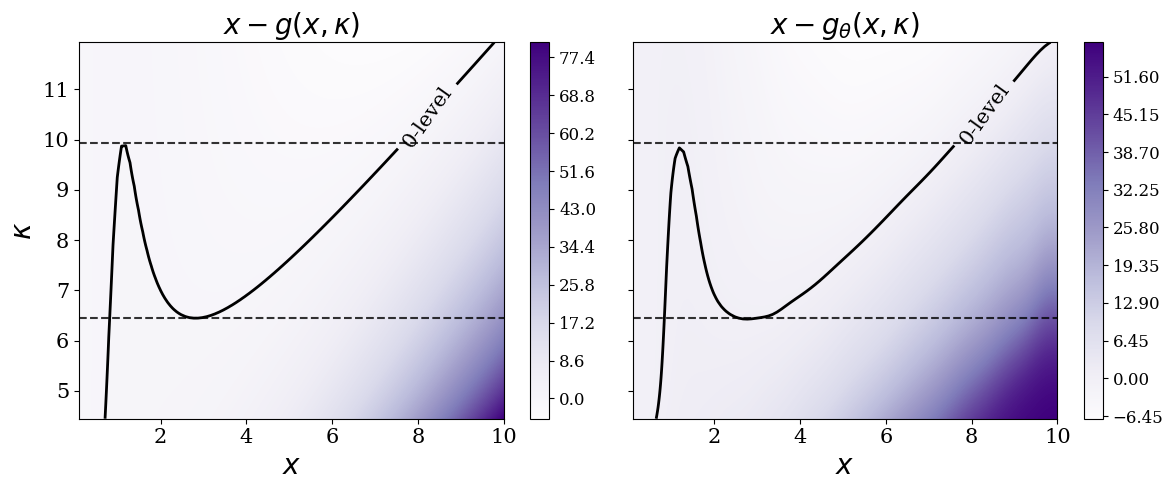

In [15]:
lam_bounds = [float(r1), float(r2)]

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# ---------------------------------------------------------
# True g plot
ax = axs[0]
contour = ax.contourf(X, L, X - Z_clipped, levels=500, cmap='Purples')
cbar = plt.colorbar(contour, ax=ax)
cbar.ax.tick_params(labelsize=12)

# Add zero contour line
zero_line = ax.contour(X, L, X - Z_clipped, levels=[0], colors='black', linewidths=2)
ax.clabel(zero_line, fmt={0: '0-level'}, fontsize=15)

for lb in lam_bounds:
    ax.axhline(lb, color='black', linestyle='--', linewidth=1.5, alpha=0.8)

ax.set_xlabel(r'$x$', fontsize=20)
ax.set_ylabel(r'$\kappa$', fontsize=20)
ax.set_title(r'$x-g(x, \kappa)$', fontsize=20)

# ---------------------------------------------------------
# NODE g plot
ax = axs[1]
contour = ax.contourf(X, L, X - Z_node_unscaled, levels=500, cmap='Purples')
cbar = plt.colorbar(contour, ax=ax)
cbar.ax.tick_params(labelsize=12)

# Add zero contour
zero_line = ax.contour(X, L, X - Z_node_unscaled, levels=[0], colors='black', linewidths=2)
ax.clabel(zero_line, fmt={0: '0-level'}, fontsize=15)

for lb in lam_bounds:
    ax.axhline(lb, color='black', linestyle='--', linewidth=1.5, alpha=0.8)

for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=15)

axs[1].set_xlabel(r'$x$', fontsize=20)
axs[1].set_title(r'$x-g_{\theta}(x, \kappa)$', fontsize=20)

plt.tight_layout()
plt.savefig("budworm-zero-set.png")
plt.show()
